In [ ]:
# Binary Classification Model — Benign vs Malignant Skin Lesions

#This notebook trains a CNN to classify skin lesion images as benign or malignant.

## Requirements
#- Dataset uploaded to Google Drive as `dataset_original`
#- Google Colab with T4 GPU enabled

## Structure
#1. Train CNN on original dataset
#2. Plot training results
#3. Evaluate on test set
#4. Predict on a single image

In [ ]:
# Step 1 — Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# ─── CONFIG ───────────────────────────────────────────────
base = "/content/dataset_original"
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 25

# ─── DATA ─────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f"{base}/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    f"{base}/Validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# ─── CNN ──────────────────────────────────────────────────
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ─── TRAIN ────────────────────────────────────────────────
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

# ─── SAVE ─────────────────────────────────────────────────
model.save("/content/drive/MyDrive/cnn_original.keras")
with open("/content/drive/MyDrive/history_original.json", "w") as f:
    json.dump(history.history, f)

print("\nDone! Model and history saved to Drive.")

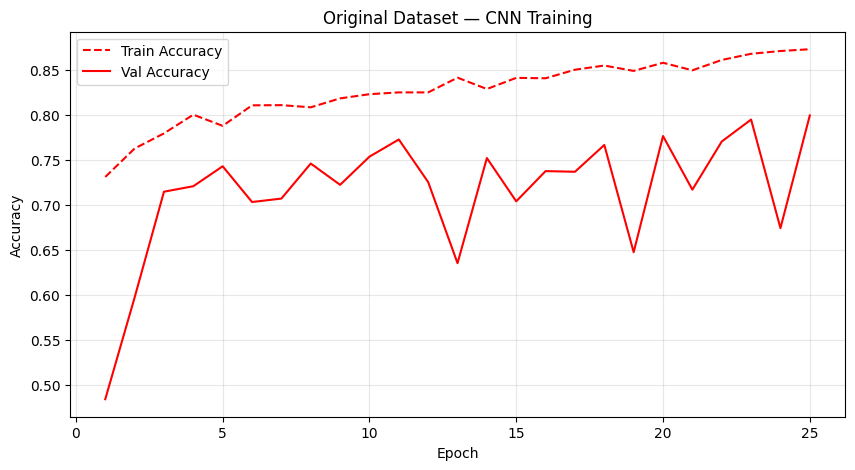

Saved!


In [ ]:
import json, matplotlib.pyplot as plt

with open("/content/drive/MyDrive/history_original.json") as f:
    h = json.load(f)

epochs = range(1, 26)
plt.figure(figsize=(10, 5))
plt.plot(epochs, h['accuracy'],     'r--', label='Train Accuracy')
plt.plot(epochs, h['val_accuracy'], 'r-',  label='Val Accuracy')
plt.title('Original Dataset — CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/original_results.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ─── LOAD MODEL ───────────────────────────────────────────
model = load_model("/content/drive/MyDrive/cnn_original.keras")

# ─── LOAD TEST DATA ───────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/content/dataset_original/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # important — keeps order for confusion matrix
)

# ─── EVALUATE ─────────────────────────────────────────────
loss, accuracy = model.evaluate(test_gen)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# ─── CONFUSION MATRIX ─────────────────────────────────────
predictions = model.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int).flatten()
true_labels = test_gen.classes

cm = confusion_matrix(true_labels, pred_labels)
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Original Dataset')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_original.png", dpi=150)
plt.show()

# ─── CLASSIFICATION REPORT ────────────────────────────────
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels,
                            target_names=class_names))



FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_original/Test'

Saving ISIC_0059975.jpg to ISIC_0059975.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


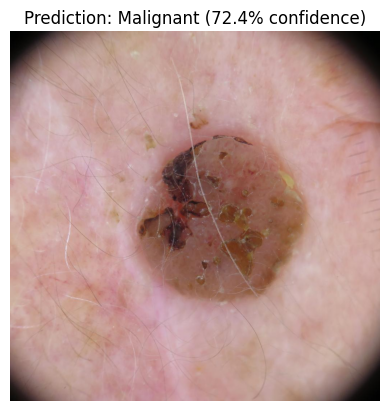

Raw score: 0.7236
Result: Malignant (72.4% confidence)


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files

# ─── LOAD MODEL ───────────────────────────────────────────
model = load_model("/content/drive/MyDrive/cnn_original.keras")

# ─── UPLOAD AN IMAGE ──────────────────────────────────────
uploaded = files.upload()  # opens a file picker
img_path = list(uploaded.keys())[0]

# ─── PREPROCESS ───────────────────────────────────────────
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

# ─── PREDICT ──────────────────────────────────────────────
prediction = model.predict(img_array)[0][0]

label = "Malignant" if prediction > 0.5 else "Benign"
confidence = prediction if prediction > 0.5 else 1 - prediction

# ─── DISPLAY ──────────────────────────────────────────────
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Prediction: {label} ({confidence*100:.1f}% confidence)")
plt.show()

print(f"Raw score: {prediction:.4f}")
print(f"Result: {label} ({confidence*100:.1f}% confidence)")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base = "/content/drive/MyDrive/dataset_benign_subtypes"
for item in os.listdir(base):
    print(item)

Training
Validation
Test


In [ ]:
import os

base = "/content/drive/MyDrive/dataset_benign_subtypes"

for split in ['Training', 'Validation', 'Test']:
    print(f"\n{split}:")
    path = os.path.join(base, split)
    for cls in os.listdir(path):
        subpath = os.path.join(path, cls)
        count = len(os.listdir(subpath))
        print(f"  {cls}: {count} images")


Training:
  Solar lentigo: 525 images
  Dermatofibroma: 525 images
  Intradermal nevus: 525 images
  Seborrhoeic keratosis: 523 images

Validation:
  Seborrhoeic keratosis: 150 images
  Intradermal nevus: 150 images
  Solar lentigo: 150 images
  Dermatofibroma: 150 images

Test:
  Dermatofibroma: 69 images
  Intradermal nevus: 75 images
  Solar lentigo: 75 images
  Seborrhoeic keratosis: 75 images


In [ ]:
import shutil, os

if not os.path.exists("/content/dataset_benign_subtypes"):
    print("Copying subtype dataset to local storage...")
    shutil.copytree(
        "/content/drive/MyDrive/dataset_benign_subtypes",
        "/content/dataset_benign_subtypes"
    )
    print("Done!")
else:
    print("Already in local storage!")

Already in local storage!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# ─── CONFIG ───────────────────────────────────────────────
base       = "/content/dataset_benign_subtypes"
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 25
NUM_CLASSES = 4

# ─── DATA ─────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f"{base}/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    f"{base}/Validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ─── CNN ──────────────────────────────────────────────────
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # 4 classes instead of 1
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

# ─── TRAIN ────────────────────────────────────────────────
history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

# ─── SAVE ─────────────────────────────────────────────────
model2.save("/content/drive/MyDrive/cnn_subtypes.keras")
with open("/content/drive/MyDrive/history_subtypes.json", "w") as f:
    json.dump(history2.history, f)

print("\nDone! Subtype model and history saved to Drive.")

Found 2098 images belonging to 4 classes.
Found 600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,924 (17.49 MB)

 Trainable params: 4,584,964 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25


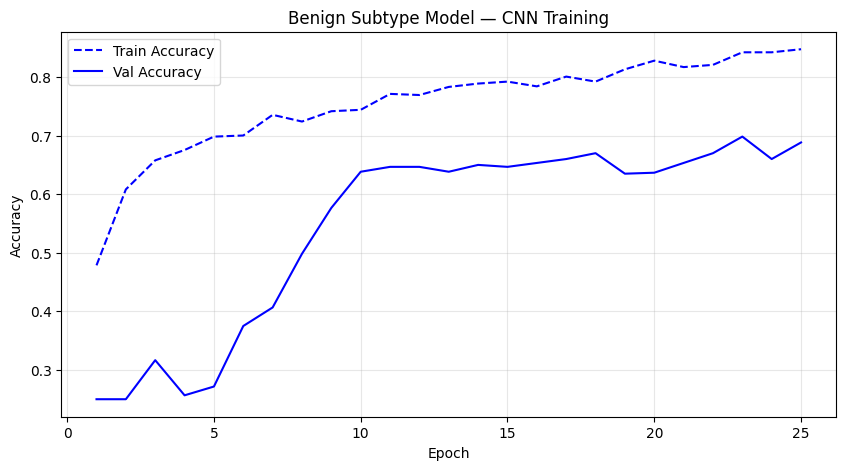

Saved!


In [ ]:
import json, matplotlib.pyplot as plt

with open("/content/drive/MyDrive/history_subtypes.json") as f:
    h = json.load(f)

epochs = range(1, 26)
plt.figure(figsize=(10, 5))
plt.plot(epochs, h['accuracy'],     'b--', label='Train Accuracy')
plt.plot(epochs, h['val_accuracy'], 'b-',  label='Val Accuracy')
plt.title('Benign Subtype Model — CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/subtypes_results.png", dpi=150)
plt.show()
print("Saved!")

Found 294 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 697ms/step - accuracy: 0.6939 - loss: 0.7911

Test Loss:     0.7911
Test Accuracy: 69.39%
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 589ms/step


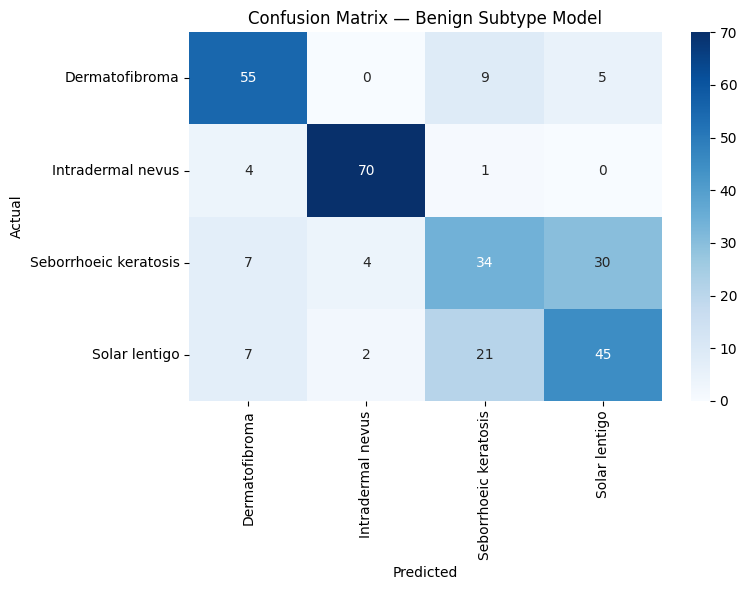


Classification Report:
                       precision    recall  f1-score   support

       Dermatofibroma       0.75      0.80      0.77        69
    Intradermal nevus       0.92      0.93      0.93        75
Seborrhoeic keratosis       0.52      0.45      0.49        75
        Solar lentigo       0.56      0.60      0.58        75

             accuracy                           0.69       294
            macro avg       0.69      0.70      0.69       294
         weighted avg       0.69      0.69      0.69       294



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ─── LOAD MODEL ───────────────────────────────────────────
model2 = load_model("/content/drive/MyDrive/cnn_subtypes.keras")

# ─── LOAD TEST DATA ───────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    "/content/dataset_benign_subtypes/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ─── EVALUATE ─────────────────────────────────────────────
loss, accuracy = model2.evaluate(test_gen)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# ─── CONFUSION MATRIX ─────────────────────────────────────
predictions = model2.predict(test_gen)
pred_labels = np.argmax(predictions, axis=1)
true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Benign Subtype Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_subtypes.png", dpi=150)
plt.show()

# ─── CLASSIFICATION REPORT ────────────────────────────────
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

Saving ISIC_0059831.jpg to ISIC_0059831.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step


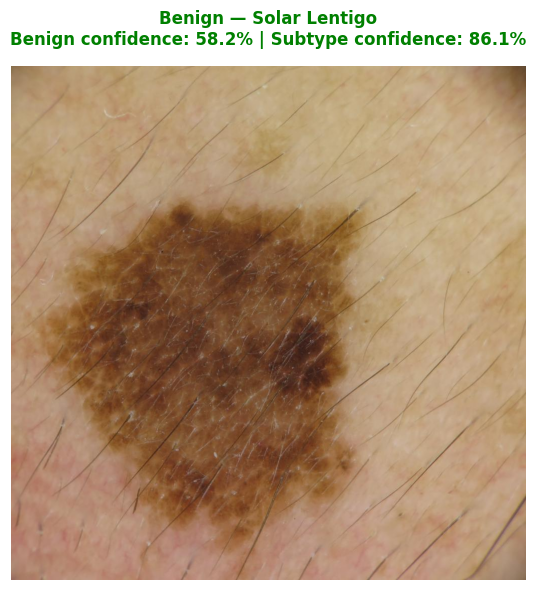


Result:  Benign — Solar Lentigo
Detail:  Benign confidence: 58.2% | Subtype confidence: 86.1%


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files

# ─── LOAD BOTH MODELS ─────────────────────────────────────
model1 = load_model("/content/drive/MyDrive/cnn_original.keras")
model2 = load_model("/content/drive/MyDrive/cnn_subtypes.keras")

# ─── SUBTYPE LABELS ───────────────────────────────────────
subtype_labels = {
    0: "Dermatofibroma",
    1: "Intradermal Nevus",
    2: "Seborrhoeic Keratosis",
    3: "Solar Lentigo"
}

# ─── UPLOAD IMAGE ─────────────────────────────────────────
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ─── PREPROCESS ───────────────────────────────────────────
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ─── MODEL 1 — BINARY ─────────────────────────────────────
binary_score = float(model1.predict(img_array)[0][0])

if binary_score > 0.5:
    # Malignant
    confidence = binary_score * 100
    final_label = "Malignant"
    colour = "red"
    detail = f"Confidence: {confidence:.1f}%"
else:
    # Benign — run Model 2 for subtype
    benign_confidence = (1 - binary_score) * 100
    subtype_scores = model2.predict(img_array)[0]
    subtype_index = np.argmax(subtype_scores)
    subtype_name = subtype_labels[subtype_index]
    subtype_confidence = float(subtype_scores[subtype_index]) * 100
    final_label = f"Benign — {subtype_name}"
    colour = "green"
    detail = f"Benign confidence: {benign_confidence:.1f}% | Subtype confidence: {subtype_confidence:.1f}%"

# ─── DISPLAY ──────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"{final_label}\n{detail}", fontsize=12,
          color=colour, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"\nResult:  {final_label}")
print(f"Detail:  {detail}")

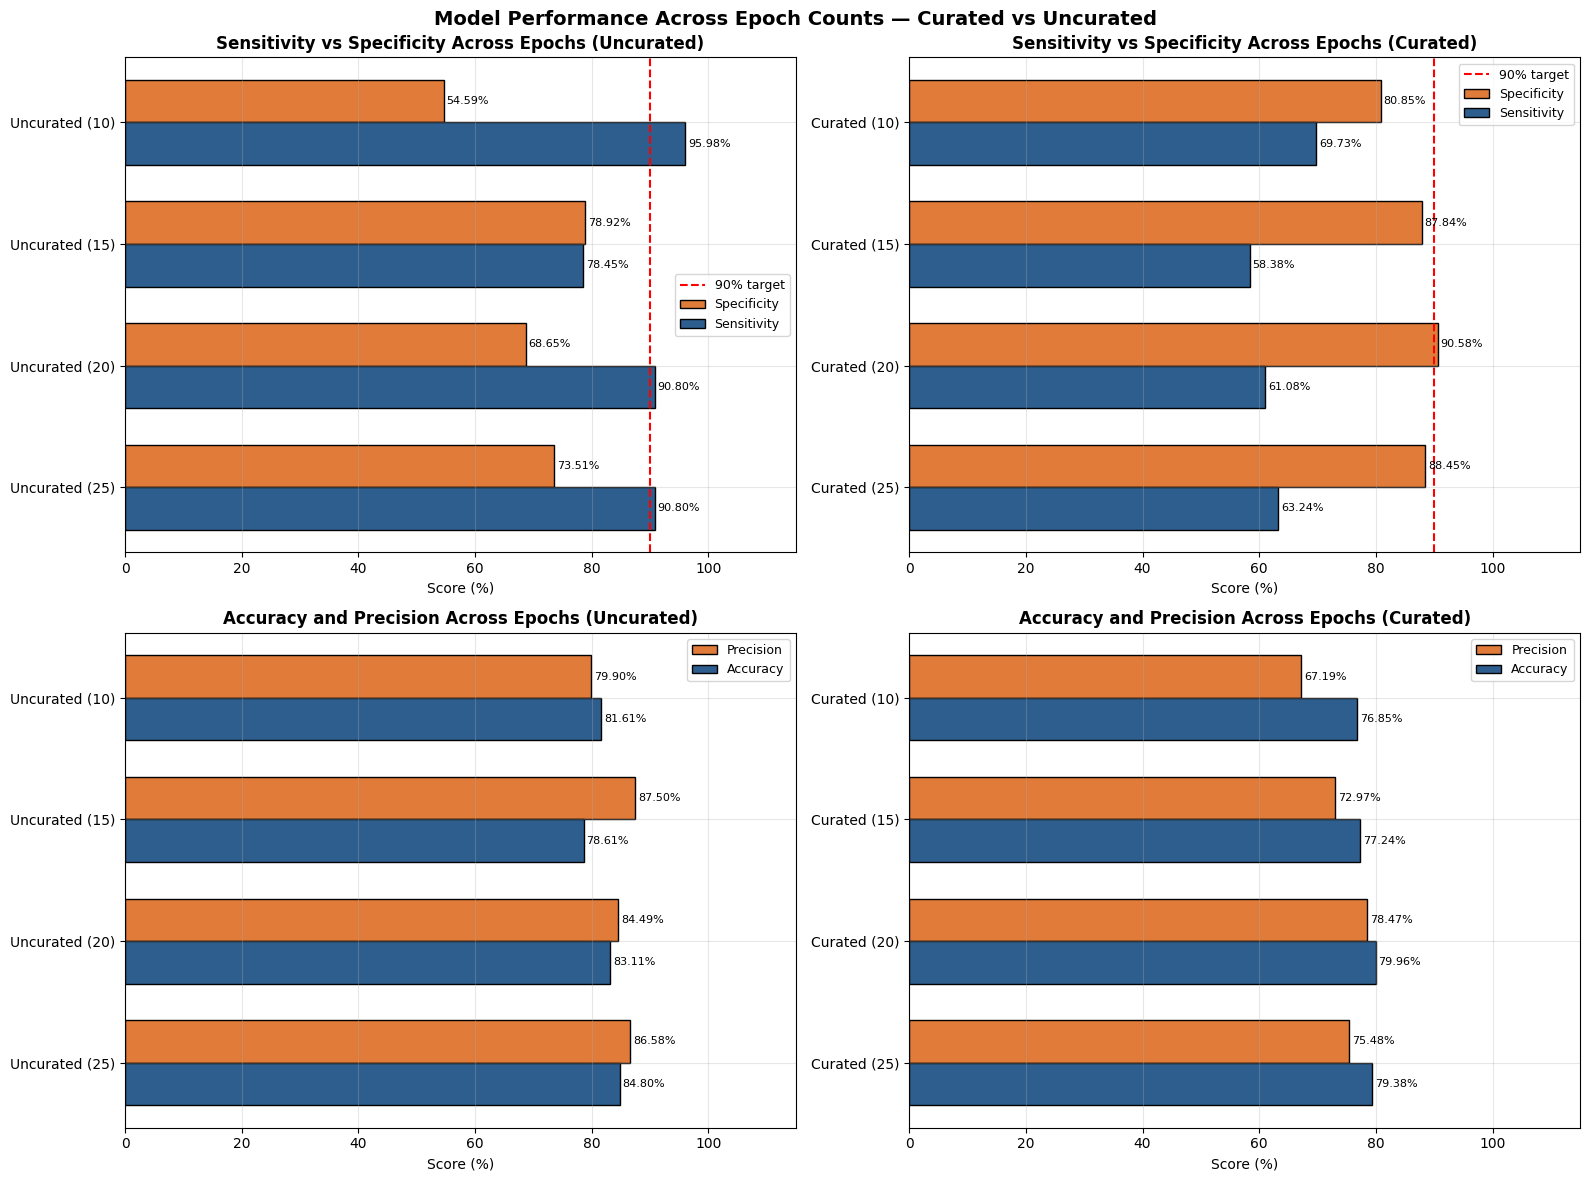

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ───────────────────────────────────────────────────────────────
epochs = ['25 Epochs', '20 Epochs', '15 Epochs', '10 Epochs']

uncurated_sensitivity = [90.80, 90.80, 78.45, 95.98]
uncurated_specificity = [73.51, 68.65, 78.92, 54.59]
uncurated_accuracy    = [84.80, 83.11, 78.61, 81.61]
uncurated_precision   = [86.58, 84.49, 87.50, 79.90]

curated_sensitivity   = [63.24, 61.08, 58.38, 69.73]
curated_specificity   = [88.45, 90.58, 87.84, 80.85]
curated_accuracy      = [79.38, 79.96, 77.24, 76.85]
curated_precision     = [75.48, 78.47, 72.97, 67.19]

# ── Plot setup ──────────────────────────────────────────────────────────
x     = np.arange(len(epochs))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Across Epoch Counts — Curated vs Uncurated',
             fontsize=14, fontweight='bold')

# ── Chart 1 — Sensitivity vs Specificity (Uncurated) ───────────────────
ax = axes[0, 0]
bars1 = ax.barh(x + width/2, uncurated_specificity, width, color='#E07B39',
                label='Specificity', edgecolor='black')
bars2 = ax.barh(x - width/2, uncurated_sensitivity, width, color='#2E5E8E',
                label='Sensitivity', edgecolor='black')
ax.axvline(x=90, color='red', linestyle='--', lw=1.5, label='90% target')
for bar in bars1:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
ax.set_yticks(x)
ax.set_yticklabels([f'Uncurated ({e.split()[0]})' for e in epochs])
ax.set_xlabel('Score (%)')
ax.set_title('Sensitivity vs Specificity Across Epochs (Uncurated)', fontweight='bold')
ax.set_xlim([0, 115])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Chart 2 — Sensitivity vs Specificity (Curated) ─────────────────────
ax = axes[0, 1]
bars1 = ax.barh(x + width/2, curated_specificity, width, color='#E07B39',
                label='Specificity', edgecolor='black')
bars2 = ax.barh(x - width/2, curated_sensitivity, width, color='#2E5E8E',
                label='Sensitivity', edgecolor='black')
ax.axvline(x=90, color='red', linestyle='--', lw=1.5, label='90% target')
for bar in bars1:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
ax.set_yticks(x)
ax.set_yticklabels([f'Curated ({e.split()[0]})' for e in epochs])
ax.set_xlabel('Score (%)')
ax.set_title('Sensitivity vs Specificity Across Epochs (Curated)', fontweight='bold')
ax.set_xlim([0, 115])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Chart 3 — Accuracy and Precision (Uncurated) ───────────────────────
ax = axes[1, 0]
bars1 = ax.barh(x + width/2, uncurated_precision, width, color='#E07B39',
                label='Precision', edgecolor='black')
bars2 = ax.barh(x - width/2, uncurated_accuracy, width, color='#2E5E8E',
                label='Accuracy', edgecolor='black')
for bar in bars1:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
ax.set_yticks(x)
ax.set_yticklabels([f'Uncurated ({e.split()[0]})' for e in epochs])
ax.set_xlabel('Score (%)')
ax.set_title('Accuracy and Precision Across Epochs (Uncurated)', fontweight='bold')
ax.set_xlim([0, 115])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Chart 4 — Accuracy and Precision (Curated) ─────────────────────────
ax = axes[1, 1]
bars1 = ax.barh(x + width/2, curated_precision, width, color='#E07B39',
                label='Precision', edgecolor='black')
bars2 = ax.barh(x - width/2, curated_accuracy, width, color='#2E5E8E',
                label='Accuracy', edgecolor='black')
for bar in bars1:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=8)
ax.set_yticks(x)
ax.set_yticklabels([f'Curated ({e.split()[0]})' for e in epochs])
ax.set_xlabel('Score (%)')
ax.set_title('Accuracy and Precision Across Epochs (Curated)', fontweight='bold')
ax.set_xlim([0, 115])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('epoch_comparison_charts.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('epoch_comparison_charts.png')
print('Done.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

════ Training Uncurated Model ════
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 70s 667ms/step - accuracy: 0.6884 - loss: 0.7432 - val_accuracy: 0.3536 - val_loss: 2.2762 - learning_rate: 1.0000e-04
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 66s 711ms/step - accuracy: 0.7295 - loss: 0.5366 - val_accuracy: 0.3536 - val_loss: 4.1506 - learning_rate: 1.0000e-04
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 587ms/step - accuracy: 0.7511 - loss: 0.5054 - val_accuracy: 0.3536 - val_loss: 4.0484 - learning_rate: 1.0000e-04
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 587ms/step - accuracy: 0.7636 - loss: 0.4963 - val_accuracy: 0.4181 - val_loss: 1.4818 - learning_rate: 1.0000e-04
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 54s 578ms/step - accuracy: 0.7568 - loss: 0.4908 - val_accuracy: 0.7832 - val_loss: 0.4577 - learning_rate: 1.0000e-04
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 560ms/step - accuracy: 0.7744 - loss: 0.4649 - val_accuracy: 0.7505 - val_loss: 0.5024 - learning_rate: 1.0000e-04
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 564ms/step - acc

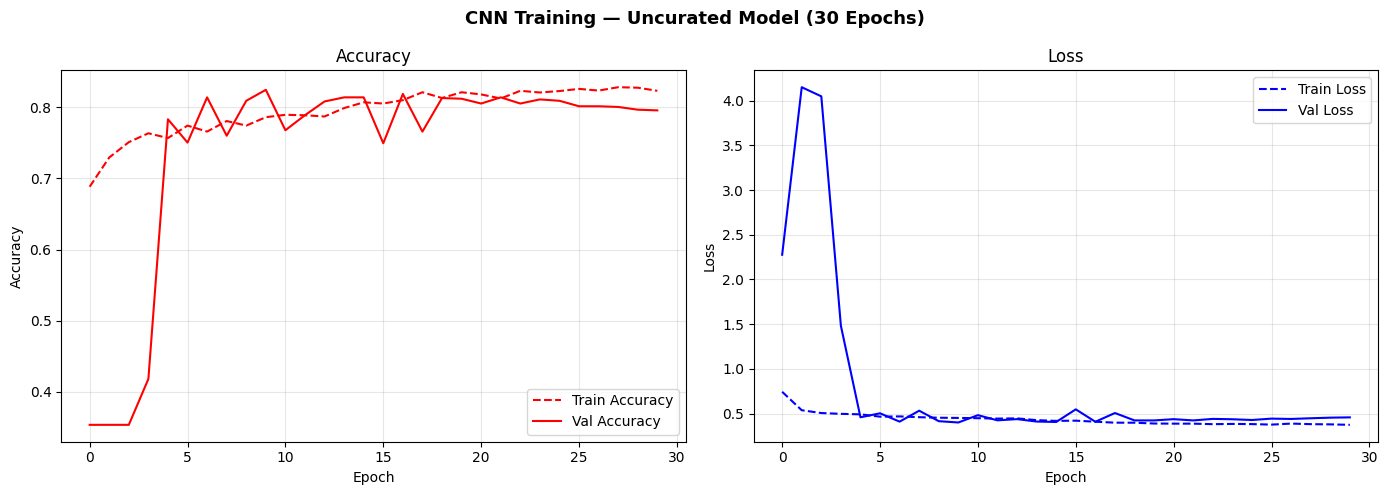


Uncurated — Best val accuracy: 82.47%
Uncurated — Epochs run: 30 / 30

════ Training Curated Model ════
Found 2955 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6487 - loss: 0.7763 - val_accuracy: 0.3914 - val_loss: 0.7485 - learning_rate: 1.0000e-04
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.7049 - loss: 0.5798 - val_accuracy: 0.6291 - val_loss: 0.6662 - learning_rate: 1.0000e-04
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7110 - loss: 0.5639 - val_accuracy: 0.6752 - val_loss: 0.6194 - learning_rate: 1.0000e-04
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 91s 982ms/step - accuracy: 0.7228 - loss: 0.5429 - val_accuracy: 0.7090 - val_loss: 0.6467 - learning_rate: 1.0000e-04
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 92s 989ms/step - accuracy: 0.7266 - loss: 0.5390 - val_accuracy: 0.7285 - val_loss: 0.5570 - learning_rate: 1.0000e-04
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━

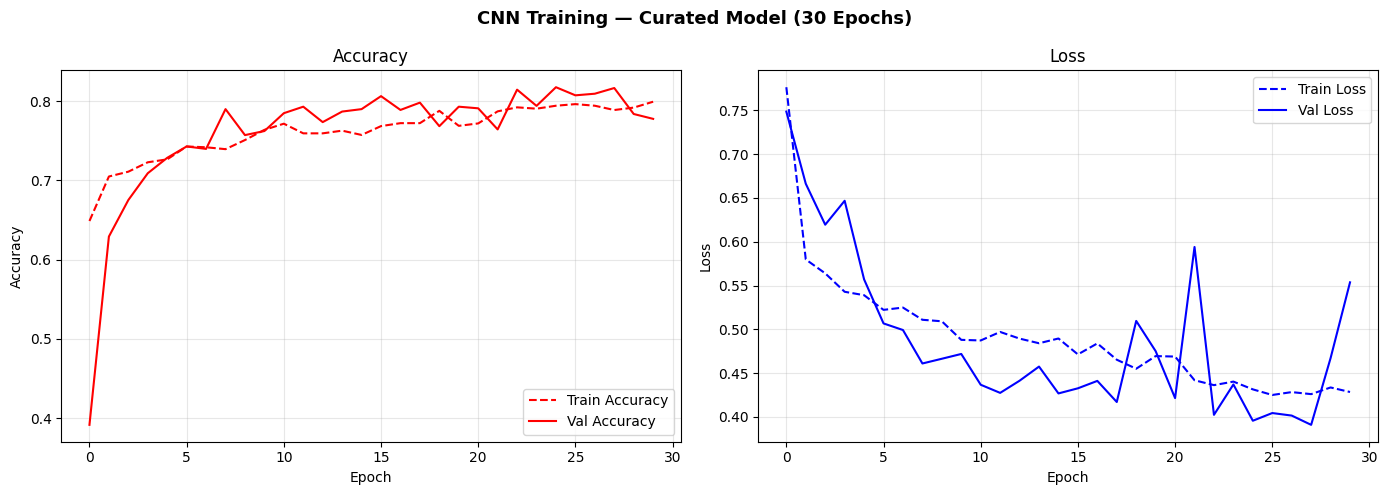


Curated — Best val accuracy: 81.76%
Curated — Epochs run: 30 / 30

════ Generating Combined Plot ════


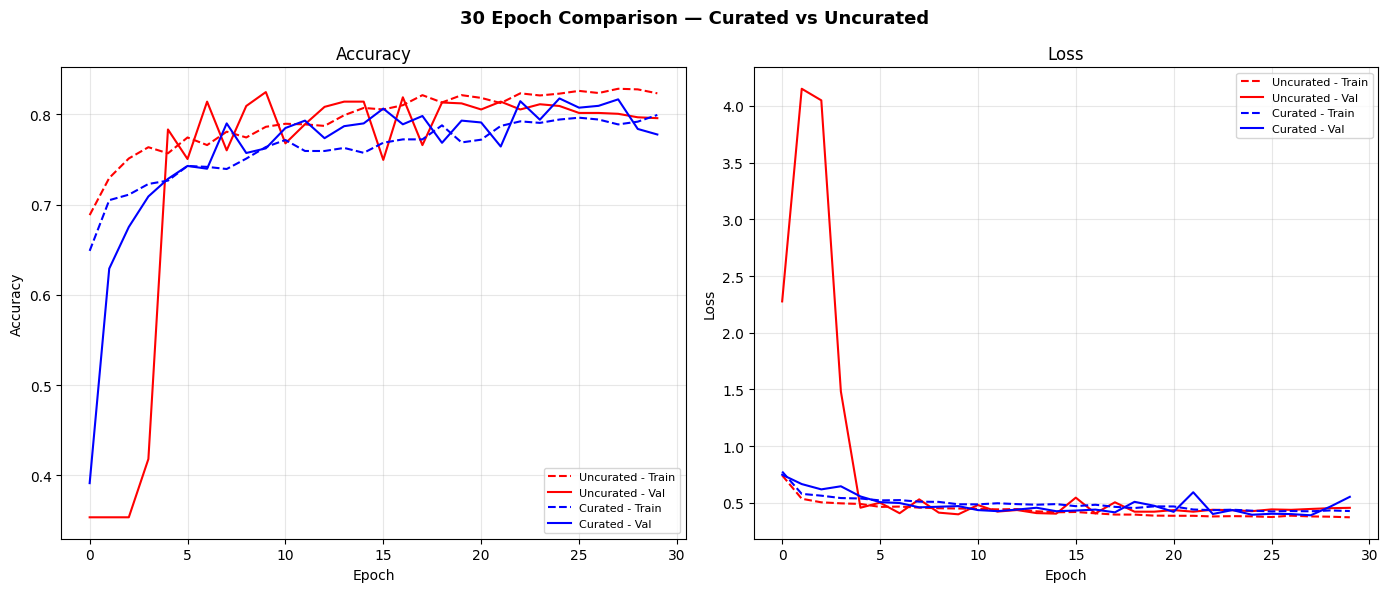


════ TRAINING COMPLETE ════
Uncurated — Best val accuracy: 82.47%
Curated   — Best val accuracy: 81.76%

Files saved to Drive:
  cnn_uncurated_30.keras
  cnn_curated_30.keras
  history_uncurated_30.json
  history_curated_30.json
  training_curves_uncurated_30.png
  training_curves_curated_30.png
  training_curves_30_combined.png


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# ─── CONFIG ───────────────────────────────────────────────
UNCURATED_DIR = "/content/drive/MyDrive/dataset_uncurated"
CURATED_DIR   = "/content/drive/MyDrive/dataset_curated"
IMG_SIZE      = (128, 128)
BATCH_SIZE    = 32
EPOCHS        = 30

# ─── DATA GENERATORS ──────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

def make_generators(base_dir):
    train_gen = train_datagen.flow_from_directory(
        f"{base_dir}/Training",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )
    val_gen = val_datagen.flow_from_directory(
        f"{base_dir}/Validation",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )
    return train_gen, val_gen

# ─── CNN BUILDER ──────────────────────────────────────────
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── CALLBACKS ────────────────────────────────────────────
def make_callbacks():
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
    return [early_stop, reduce_lr]

# ─── PLOT FUNCTION ─────────────────────────────────────────
def plot_history(history, label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'CNN Training — {label} (30 Epochs)', fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     'r--', label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], 'r-',  label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     'b--', label='Train Loss')
    axes[1].plot(history.history['val_loss'], 'b-',  label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# ─── COMBINED PLOT ─────────────────────────────────────────
def plot_combined(hist_unc, hist_cur):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('30 Epoch Comparison — Curated vs Uncurated', fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(hist_unc.history['accuracy'],     'r--', label='Uncurated - Train')
    axes[0].plot(hist_unc.history['val_accuracy'], 'r-',  label='Uncurated - Val')
    axes[0].plot(hist_cur.history['accuracy'],     'b--', label='Curated - Train')
    axes[0].plot(hist_cur.history['val_accuracy'], 'b-',  label='Curated - Val')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(hist_unc.history['loss'],     'r--', label='Uncurated - Train')
    axes[1].plot(hist_unc.history['val_loss'], 'r-',  label='Uncurated - Val')
    axes[1].plot(hist_cur.history['loss'],     'b--', label='Curated - Train')
    axes[1].plot(hist_cur.history['val_loss'], 'b-',  label='Curated - Val')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/training_curves_30_combined.png', dpi=300)
    plt.show()

# ════════════════════════════════════════════════════════════
# TRAIN UNCURATED
# ════════════════════════════════════════════════════════════
print('\n════ Training Uncurated Model ════')
unc_train, unc_val = make_generators(UNCURATED_DIR)
model_uncurated = build_model()
model_uncurated.summary()

history_uncurated = model_uncurated.fit(
    unc_train,
    validation_data=unc_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_uncurated.save('/content/drive/MyDrive/cnn_uncurated_30.keras')
with open('/content/drive/MyDrive/history_uncurated_30.json', 'w') as f:
    json.dump(history_uncurated.history, f)

plot_history(history_uncurated, 'Uncurated Model',
             '/content/drive/MyDrive/training_curves_uncurated_30.png')

print(f'\nUncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Uncurated — Epochs run: {len(history_uncurated.history["accuracy"])} / {EPOCHS}')

# ════════════════════════════════════════════════════════════
# TRAIN CURATED
# ════════════════════════════════════════════════════════════
print('\n════ Training Curated Model ════')
cur_train, cur_val = make_generators(CURATED_DIR)
model_curated = build_model()

history_curated = model_curated.fit(
    cur_train,
    validation_data=cur_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_curated.save('/content/drive/MyDrive/cnn_curated_30.keras')
with open('/content/drive/MyDrive/history_curated_30.json', 'w') as f:
    json.dump(history_curated.history, f)

plot_history(history_curated, 'Curated Model',
             '/content/drive/MyDrive/training_curves_curated_30.png')

print(f'\nCurated — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
print(f'Curated — Epochs run: {len(history_curated.history["accuracy"])} / {EPOCHS}')

# ════════════════════════════════════════════════════════════
# COMBINED COMPARISON PLOT
# ════════════════════════════════════════════════════════════
print('\n════ Generating Combined Plot ════')
plot_combined(history_uncurated, history_curated)

# ─── SUMMARY ──────────────────────────────────────────────
print('\n════ TRAINING COMPLETE ════')
print(f'Uncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Curated   — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
print('\nFiles saved to Drive:')
print('  cnn_uncurated_30.keras')
print('  cnn_curated_30.keras')
print('  history_uncurated_30.json')
print('  history_curated_30.json')
print('  training_curves_uncurated_30.png')
print('  training_curves_curated_30.png')
print('  training_curves_30_combined.png')

In [ ]:
import shutil
import os
from google.colab import drive
drive.mount('/content/drive')

# ─── COPY DATASETS FROM DRIVE TO LOCAL ────────────────────
print('Copying datasets to local storage...')

if not os.path.exists('/content/dataset_uncurated'):
    shutil.copytree('/content/drive/MyDrive/dataset_uncurated',
                    '/content/dataset_uncurated')
    print('Uncurated dataset copied.')
else:
    print('Uncurated dataset already exists locally.')

if not os.path.exists('/content/dataset_curated'):
    shutil.copytree('/content/drive/MyDrive/dataset_curated',
                    '/content/dataset_curated')
    print('Curated dataset copied.')
else:
    print('Curated dataset already exists locally.')

print('Done — datasets ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying datasets to local storage...
Uncurated dataset copied.
Curated dataset copied.
Done — datasets ready.


In [ ]:
import shutil
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying datasets...
Uncurated copied.
Curated copied.

Loading models...
Models loaded.
Found 1038 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 288ms/step

Uncurated (30 epochs) — Metrics:
  Accuracy:    82.47%
  Sensitivity: 92.70%
  Specificity: 63.76%
  Precision:   82.38%
  F1 Score:    0.8724
  TP:622  TN:234  FP:133  FN:49
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 633ms/step

Curated (30 epochs) — Metrics:
  Accuracy:    81.66%
  Sensitivity: 75.75%
  Specificity: 85.22%
  Precision:   75.54%
  F1 Score:    0.7565
  TP:278  TN:519  FP:90  FN:89

Loading training histories...


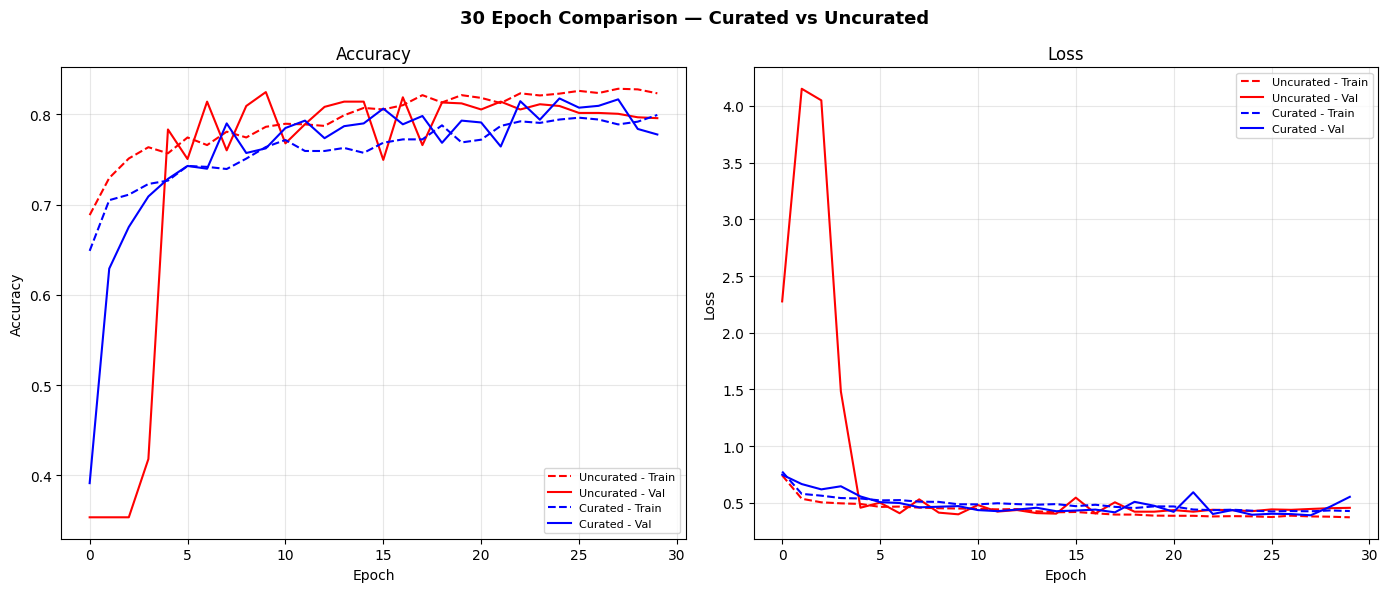


════ FINAL SUMMARY — 30 EPOCHS ════
Metric             Uncurated      Curated
─────────────────────────────────────────
Accuracy               82.47        81.66
Sensitivity             92.7        75.75
Specificity            63.76        85.22
Precision              82.38        75.54
F1 Score              0.8724       0.7565

TP           622           278
TN           234           519
FP           133            90
FN            49            89


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive, files
import os, shutil

drive.mount('/content/drive')

# ─── COPY DATASETS TO LOCAL ────────────────────────────────
print('Copying datasets...')
if not os.path.exists('/content/dataset_uncurated'):
    shutil.copytree('/content/drive/MyDrive/dataset_uncurated',
                    '/content/dataset_uncurated')
    print('Uncurated copied.')
else:
    print('Uncurated already local.')

if not os.path.exists('/content/dataset_curated'):
    shutil.copytree('/content/drive/MyDrive/dataset_curated',
                    '/content/dataset_curated')
    print('Curated copied.')
else:
    print('Curated already local.')

# ─── CONFIG ────────────────────────────────────────────────
UNCURATED_MODEL = '/content/drive/MyDrive/cnn_uncurated_30.keras'
CURATED_MODEL   = '/content/drive/MyDrive/cnn_curated_30.keras'
UNCURATED_DIR   = '/content/dataset_uncurated'
CURATED_DIR     = '/content/dataset_curated'
IMG_SIZE        = (128, 128)
BATCH_SIZE      = 32

# ─── LOAD MODELS ───────────────────────────────────────────
print('\nLoading models...')
model_unc = load_model(UNCURATED_MODEL)
model_cur = load_model(CURATED_MODEL)
print('Models loaded.')

# ─── VAL GENERATORS ────────────────────────────────────────
val_datagen = ImageDataGenerator(rescale=1./255)

unc_val = val_datagen.flow_from_directory(
    f'{UNCURATED_DIR}/Validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
cur_val = val_datagen.flow_from_directory(
    f'{CURATED_DIR}/Validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ─── EVALUATION ────────────────────────────────────────────
def evaluate_model(model, val_gen, label):
    val_gen.reset()
    probs  = model.predict(val_gen, verbose=1).ravel()
    labels = val_gen.classes
    preds  = (probs >= 0.5).astype(int)

    tp = np.sum((preds == 1) & (labels == 1))
    tn = np.sum((preds == 0) & (labels == 0))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy    = (tp + tn) / len(labels)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    print(f'\n{label} — Metrics:')
    print(f'  Accuracy:    {accuracy*100:.2f}%')
    print(f'  Sensitivity: {sensitivity*100:.2f}%')
    print(f'  Specificity: {specificity*100:.2f}%')
    print(f'  Precision:   {precision*100:.2f}%')
    print(f'  F1 Score:    {f1:.4f}')
    print(f'  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}')

    return {
        'Accuracy':    round(accuracy*100, 2),
        'Sensitivity': round(sensitivity*100, 2),
        'Specificity': round(specificity*100, 2),
        'Precision':   round(precision*100, 2),
        'F1 Score':    round(f1, 4),
        'TP': int(tp), 'TN': int(tn),
        'FP': int(fp), 'FN': int(fn)
    }

metrics_unc = evaluate_model(model_unc, unc_val, 'Uncurated (30 epochs)')
metrics_cur = evaluate_model(model_cur, cur_val, 'Curated (30 epochs)')

# ─── LOAD HISTORY AND PLOT ─────────────────────────────────
print('\nLoading training histories...')
with open('/content/drive/MyDrive/history_uncurated_30.json') as f:
    hist_unc = json.load(f)
with open('/content/drive/MyDrive/history_curated_30.json') as f:
    hist_cur = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('30 Epoch Comparison — Curated vs Uncurated',
             fontsize=13, fontweight='bold')

axes[0].plot(hist_unc['accuracy'],     'r--', label='Uncurated - Train')
axes[0].plot(hist_unc['val_accuracy'], 'r-',  label='Uncurated - Val')
axes[0].plot(hist_cur['accuracy'],     'b--', label='Curated - Train')
axes[0].plot(hist_cur['val_accuracy'], 'b-',  label='Curated - Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_unc['loss'],     'r--', label='Uncurated - Train')
axes[1].plot(hist_unc['val_loss'], 'r-',  label='Uncurated - Val')
axes[1].plot(hist_cur['loss'],     'b--', label='Curated - Train')
axes[1].plot(hist_cur['val_loss'], 'b-',  label='Curated - Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_30_combined.png', dpi=300)
plt.show()

# ─── SUMMARY TABLE ─────────────────────────────────────────
print('\n════ FINAL SUMMARY — 30 EPOCHS ════')
print(f'{"Metric":<15} {"Uncurated":>12} {"Curated":>12}')
print('─' * 41)
for key in ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']:
    print(f'{key:<15} {str(metrics_unc[key]):>12} {str(metrics_cur[key]):>12}')
print(f'\nTP  {metrics_unc["TP"]:>12}  {metrics_cur["TP"]:>12}')
print(f'TN  {metrics_unc["TN"]:>12}  {metrics_cur["TN"]:>12}')
print(f'FP  {metrics_unc["FP"]:>12}  {metrics_cur["FP"]:>12}')
print(f'FN  {metrics_unc["FN"]:>12}  {metrics_cur["FN"]:>12}')

files.download('/content/drive/MyDrive/training_curves_30_combined.png')
print('\nDone.')

Mounted at /content/drive


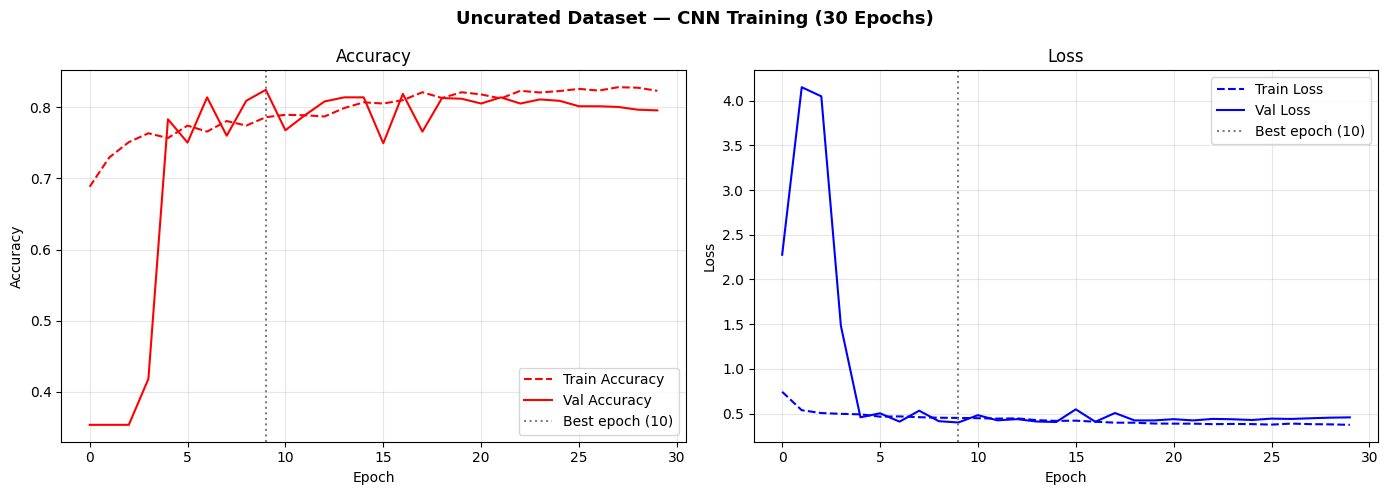

Best val accuracy: 82.47% at epoch 10
Final val accuracy: 79.58%
Total epochs: 30


In [ ]:
import json
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Load both histories
with open('/content/drive/MyDrive/history_uncurated_30.json') as f:
    hist_unc = json.load(f)

with open('/content/drive/MyDrive/history_curated_30.json') as f:
    hist_cur = json.load(f)

# Plot uncurated 30 epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Uncurated Dataset — CNN Training (30 Epochs)', fontsize=13, fontweight='bold')

axes[0].plot(hist_unc['accuracy'],     'r--', label='Train Accuracy')
axes[0].plot(hist_unc['val_accuracy'], 'r-',  label='Val Accuracy')
axes[0].axvline(x=9, color='grey', linestyle=':', lw=1.5, label='Best epoch (10)')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_unc['loss'],     'b--', label='Train Loss')
axes[1].plot(hist_unc['val_loss'], 'b-',  label='Val Loss')
axes[1].axvline(x=9, color='grey', linestyle=':', lw=1.5, label='Best epoch (10)')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_uncurated_30_final.png', dpi=300)
plt.show()

# Print key stats
print(f'Best val accuracy: {max(hist_unc["val_accuracy"])*100:.2f}% at epoch {hist_unc["val_accuracy"].index(max(hist_unc["val_accuracy"]))+1}')
print(f'Final val accuracy: {hist_unc["val_accuracy"][-1]*100:.2f}%')
print(f'Total epochs: {len(hist_unc["accuracy"])}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


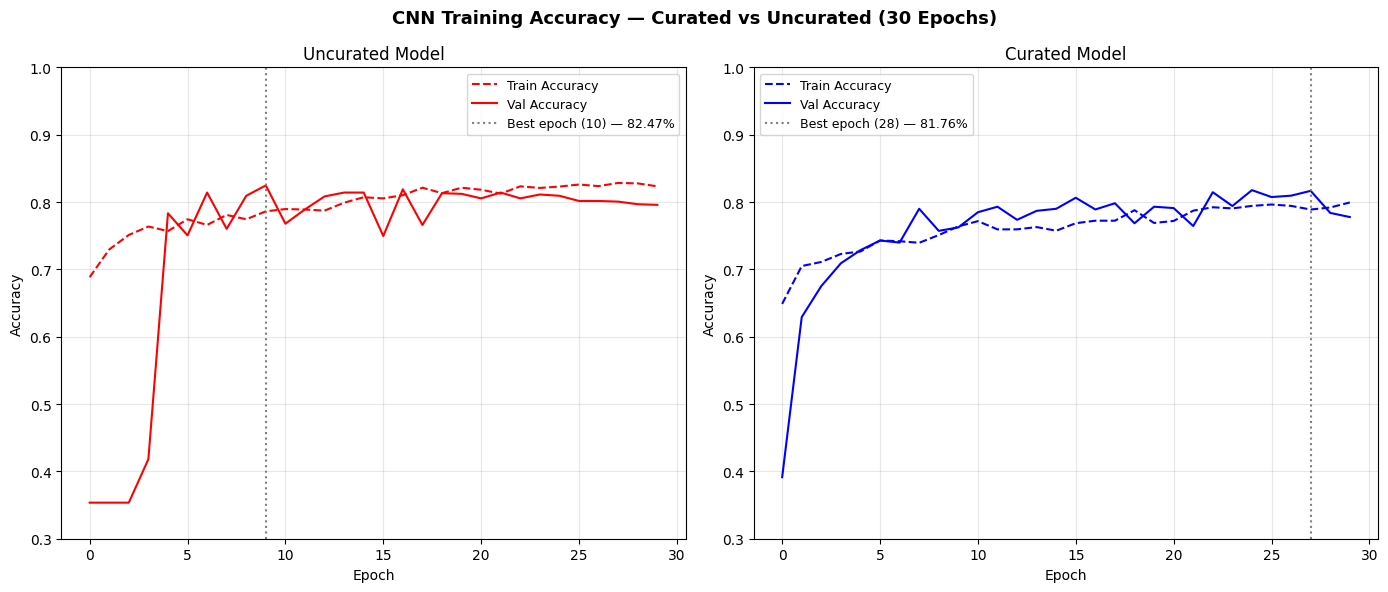

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


In [ ]:
import json
import matplotlib.pyplot as plt
from google.colab import drive, files
drive.mount('/content/drive')

# Load histories
with open('/content/drive/MyDrive/history_uncurated_30.json') as f:
    hist_unc = json.load(f)

with open('/content/drive/MyDrive/history_curated_30.json') as f:
    hist_cur = json.load(f)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CNN Training Accuracy — Curated vs Uncurated (30 Epochs)',
             fontsize=13, fontweight='bold')

# Uncurated
axes[0].plot(hist_unc['accuracy'],     'r--', label='Train Accuracy')
axes[0].plot(hist_unc['val_accuracy'], 'r-',  label='Val Accuracy')
axes[0].axvline(x=9,  color='grey', linestyle=':', lw=1.5, label='Best epoch (10) — 82.47%')
axes[0].set_title('Uncurated Model', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.3, 1.0])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Curated
axes[1].plot(hist_cur['accuracy'],     'b--', label='Train Accuracy')
axes[1].plot(hist_cur['val_accuracy'], 'b-',  label='Val Accuracy')
axes[1].axvline(x=27, color='grey', linestyle=':', lw=1.5, label='Best epoch (28) — 81.76%')
axes[1].set_title('Curated Model', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.3, 1.0])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/accuracy_30_epochs.png', dpi=300)
plt.show()

files.download('/content/drive/MyDrive/accuracy_30_epochs.png')
print('Done.')


In [ ]:
import json
import pandas as pd
from google.colab import drive, files
drive.mount('/content/drive')

# Load histories
with open('/content/drive/MyDrive/history_uncurated_30.json') as f:
    hist_unc = json.load(f)

with open('/content/drive/MyDrive/history_curated_30.json') as f:
    hist_cur = json.load(f)

# Build dataframes
epochs = range(1, len(hist_unc['accuracy']) + 1)

df_unc = pd.DataFrame({
    'Epoch':               epochs,
    'Uncurated Train Accuracy': [round(x*100, 2) for x in hist_unc['accuracy']],
    'Uncurated Val Accuracy':   [round(x*100, 2) for x in hist_unc['val_accuracy']],
    'Uncurated Train Loss':     [round(x, 4)     for x in hist_unc['loss']],
    'Uncurated Val Loss':       [round(x, 4)     for x in hist_unc['val_loss']],
})

df_cur = pd.DataFrame({
    'Epoch':             epochs,
    'Curated Train Accuracy': [round(x*100, 2) for x in hist_cur['accuracy']],
    'Curated Val Accuracy':   [round(x*100, 2) for x in hist_cur['val_accuracy']],
    'Curated Train Loss':     [round(x, 4)     for x in hist_cur['loss']],
    'Curated Val Loss':       [round(x, 4)     for x in hist_cur['val_loss']],
})

# Merge into one sheet
df_combined = pd.merge(df_unc, df_cur, on='Epoch')

# Save to Excel
output_path = '/content/drive/MyDrive/training_history_30_epochs.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_combined.to_excel(writer, sheet_name='Combined', index=False)
    df_unc.to_excel(writer, sheet_name='Uncurated', index=False)
    df_cur.to_excel(writer, sheet_name='Curated',   index=False)

files.download(output_path)
print('Done — training_history_30_epochs.xlsx downloaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — training_history_30_epochs.xlsx downloaded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive, files

# ── MOUNT DRIVE ───────────────────────────────────────
drive.mount('/content/drive')

# ── CONFIG ────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'

IMG_SIZE = (128, 128)

# FST images
FST1_M = '/content/drive/MyDrive/Skin Type/FST 1 M.jpg'
FST6_M = '/content/drive/MyDrive/Skin Type/FST6 M.png'

# ── LOAD + FIX MODELS (CRITICAL FIX) ──────────────────
def make_functional(model):
    inputs = tf.keras.Input(shape=(128, 128, 3))
    outputs = model(inputs, training=False)
    return tf.keras.Model(inputs, outputs)

curated_model   = make_functional(load_model(CURATED_MODEL_PATH))
uncurated_model = make_functional(load_model(UNCURATED_MODEL_PATH))


# ── BUILD GRADCAM MODELS ─────────────────────────────
def build_grad_model(model):
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer
            break

    return tf.keras.Model(
        inputs=model.input,
        outputs=[last_conv.output, model.output]
    )

unc_grad_model = build_grad_model(uncurated_model)
cur_grad_model = build_grad_model(curated_model)


# ── GRADCAM FUNCTION ─────────────────────────────────
def make_gradcam_heatmap(img_array, grad_model):

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        # Handle sigmoid vs softmax
        if predictions.shape[-1] == 1:
            class_channel = predictions[:, 0]
        else:
            class_idx = tf.argmax(predictions[0])
            class_channel = predictions[:, class_idx]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    # Confidence
    if predictions.shape[-1] == 1:
        confidence = float(predictions[0][0])
    else:
        idx = tf.argmax(predictions[0])
        confidence = float(predictions[0][idx])

    return heatmap.numpy(), confidence


# ── OVERLAY FUNCTION ─────────────────────────────────
def overlay_gradcam(img_path, grad_model):

    img = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    inp = np.expand_dims(img_arr, axis=0)

    heatmap, confidence = make_gradcam_heatmap(inp, grad_model)

    heatmap = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE)
    heatmap = tf.squeeze(heatmap).numpy()

    colored = cm.jet(heatmap)[:, :, :3]

    # cleaner blending
    overlay = np.clip(img_arr * 0.7 + colored * 0.3, 0, 1)

    return overlay, confidence


# ── GENERATE RESULTS ─────────────────────────────────
# Columns: FST I | FST VI
# Rows: Uncurated | Curated

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

fig.suptitle(
    'GradCAM — FST I vs FST VI (Curated vs Uncurated, 25 Epochs)',
    fontsize=12,
    fontweight='bold'
)

# ── UNCURATED ROW ──
img_u1, conf_u1 = overlay_gradcam(FST1_M, unc_grad_model)
img_u6, conf_u6 = overlay_gradcam(FST6_M, unc_grad_model)

axes[0, 0].imshow(img_u1)
axes[0, 0].set_title(f'Uncurated — FST I\n{conf_u1*100:.1f}%', fontsize=9)
axes[0, 0].axis('off')

axes[0, 1].imshow(img_u6)
axes[0, 1].set_title(f'Uncurated — FST VI\n{conf_u6*100:.1f}%', fontsize=9)
axes[0, 1].axis('off')

# ── CURATED ROW ──
img_c1, conf_c1 = overlay_gradcam(FST1_M, cur_grad_model)
img_c6, conf_c6 = overlay_gradcam(FST6_M, cur_grad_model)

axes[1, 0].imshow(img_c1)
axes[1, 0].set_title(f'Curated — FST I\n{conf_c1*100:.1f}%', fontsize=9)
axes[1, 0].axis('off')

axes[1, 1].imshow(img_c6)
axes[1, 1].set_title(f'Curated — FST VI\n{conf_c6*100:.1f}%', fontsize=9)
axes[1, 1].axis('off')

# Labels
axes[0, 0].set_ylabel('Uncurated', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Curated', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/gradcam_fst_final.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('/content/gradcam_fst_final.png')

print("Done.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


AttributeError: 'NoneType' object has no attribute 'output'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from google.colab import drive, files

drive.mount('/content/drive', force_remount=True)

# ── Config ─────────────────────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
CURATED_TEST_DIR     = '/content/drive/MyDrive/dataset_curated/Test'
UNCURATED_TEST_DIR   = '/content/drive/MyDrive/dataset_uncurated/Test'

IMG_SIZE = (128, 128)
BATCH    = 32

# ── Data generators ─────────────────────────────────────────────────────
def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255)
    return datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        shuffle=False
    )

curated_test   = make_test_generator(CURATED_TEST_DIR)
uncurated_test = make_test_generator(UNCURATED_TEST_DIR)

print(f'Curated   — {len(curated_test.classes)} samples | {curated_test.class_indices}')
print(f'Uncurated — {len(uncurated_test.classes)} samples | {uncurated_test.class_indices}')

# ── Load models ─────────────────────────────────────────────────────────
curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# ── Predictions ─────────────────────────────────────────────────────────
print('\nRunning predictions...')
curated_probs   = curated_model.predict(curated_test,   verbose=1).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test, verbose=1).ravel()

curated_preds   = (curated_probs   >= 0.5).astype(int)
uncurated_preds = (uncurated_probs >= 0.5).astype(int)

curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

# ── Confusion matrices ──────────────────────────────────────────────────
cm_c = confusion_matrix(curated_labels,   curated_preds)
cm_u = confusion_matrix(uncurated_labels, uncurated_preds)

# ── Metrics ─────────────────────────────────────────────────────────────
def get_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) \
                  if (precision + sensitivity) > 0 else 0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    return tn, fp, fn, tp, sensitivity, specificity, precision, f1, accuracy

tn_c, fp_c, fn_c, tp_c, sens_c, spec_c, prec_c, f1_c, acc_c = get_metrics(cm_c)
tn_u, fp_u, fn_u, tp_u, sens_u, spec_u, prec_u, f1_u, acc_u = get_metrics(cm_u)

print(f'\nCurated   — Sensitivity: {sens_c:.3f} | Specificity: {spec_c:.3f} | '
      f'F1: {f1_c:.3f} | Accuracy: {acc_c:.3f}')
print(f'Uncurated — Sensitivity: {sens_u:.3f} | Specificity: {spec_u:.3f} | '
      f'F1: {f1_u:.3f} | Accuracy: {acc_u:.3f}')

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Curated vs Uncurated Model (25 Epochs)',
             fontsize=14, fontweight='bold', y=1.02)

class_names = ['Benign', 'Malignant']

for ax, cm, title, colour, metrics in [
    (axes[0], cm_u, 'Uncurated Model (25 Epochs)', 'Blues',
     (sens_u, spec_u, prec_u, f1_u, acc_u,
      tp_u, tn_u, fp_u, fn_u)),
    (axes[1], cm_c, 'Curated Model (25 Epochs)',   'Oranges',
     (sens_c, spec_c, prec_c, f1_c, acc_c,
      tp_c, tn_c, fp_c, fn_c)),
]:
    sens, spec, prec, f1, acc, tp, tn, fp, fn = metrics

    sns.heatmap(
        cm, annot=True, fmt='d', cmap=colour,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5,
        annot_kws={'size': 14, 'weight': 'bold'},
        cbar=False
    )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.tick_params(labelsize=10)

    # Metrics box below the heatmap
    metrics_text = (
        f'Sensitivity: {sens:.1%}   Specificity: {spec:.1%}\n'
        f'Precision:   {prec:.1%}   F1 Score:    {f1:.3f}\n'
        f'Accuracy:    {acc:.1%}\n'
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}'
    )
    ax.text(0.5, -0.22, metrics_text,
            transform=ax.transAxes,
            fontsize=9, ha='center', va='top',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/confusion_matrix_25epochs.png',
            dpi=300, bbox_inches='tight')
plt.show()

files.download('/content/confusion_matrix_25epochs.png')
print('\nDone.')


Mounted at /content/drive
Found 514 images belonging to 2 classes.
Mounted at /content/drive
Found 514 images belonging to 2 classes.
Found 533 images belonging to 2 classes.
Found 533 images belonging to 2 classes.
Curated   — 514 samples | {'Benign': 0, 'Malignant': 1}
Uncurated — 533 samples | {'Benign': 0, 'Malignant': 1}
Curated   — 514 samples | {'Benign': 0, 'Malignant': 1}
Uncurated — 533 samples | {'Benign': 0, 'Malignant': 1}

Running predictions...

Running predictions...
 2/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step 